In [2]:
from time import time
import pandas as pd
import numpy as np
from collections import OrderedDict
import warnings

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestClassifier, ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

from sklearn.preprocessing import StandardScaler

In [3]:
from plot_design import *

In [4]:
def instantiate_model(model_name):
    model = model_name()
    return model

def fit_model(model, X_train, y_train):
    ti = time()
    model = instantiate_model(model)
    model.fit(X_train, y_train)
    fit_time = time() - ti
    return model, fit_time

def append_result_df(df, result_dict):
    df_result_appended = pd.concat([df, pd.DataFrame([result_dict])], ignore_index=True)
    return df_result_appended

def append_model_dict(dic, model_name, model):
    dic[model_name] = model
    return dic

def evaluate_model(model, X, y_act):
    y_pred = model.predict(X)
    acc = accuracy_score(y_act, y_pred)
    f1 = f1_score(y_act, y_pred, average="weighted", zero_division=0)
    precision = precision_score(y_act, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_act, y_pred, average="weighted", zero_division=0)
    return acc, f1, precision, recall

def fit_evaluate_model(model, model_name, X_train, y_train, X_val, y_val):
    model, fit_time = fit_model(model, X_train, y_train)
    acc_train, f1_train, prec_train, rec_train = evaluate_model(model, X_train, y_train)
    acc_val, f1_val, prec_val, rec_val = evaluate_model(model, X_val, y_val)
    result_dict = {
        'model_name': model_name,
        'model_name_pretty': type(model).__name__,
        'model_params': model.get_params(),
        'fit_time': fit_time,
        'acc_train': acc_train,
        'f1_train': f1_train,
        'precision_train': prec_train,
        'recall_train': rec_train,
        'acc_val': acc_val,
        'f1_val': f1_val,
        'precision_val': prec_val,
        'recall_val': rec_val,
    }
    return model, result_dict

# Read in featurised dataset

In [5]:
df_train = pd.read_csv('approx_dataset_splits/app_train_split.csv')
df_test = pd.read_csv('approx_dataset_splits/app_test_split.csv')
df_val = pd.read_csv('approx_dataset_splits/app_val_split.csv')

In [6]:
df_train["Crystal_System"] = df_train["Crystal_System"].astype("category")
df_test["Crystal_System"] = df_test["Crystal_System"].astype("category")
df_val["Crystal_System"] = df_val["Crystal_System"].astype("category")


df_train["target"] = df_train["Crystal_System"].cat.codes
df_test["target"] = df_test["Crystal_System"].cat.codes
df_val["target"] = df_val["Crystal_System"].cat.codes

label_mapping = dict(enumerate(df_train["Crystal_System"].cat.categories))

# Define which columns are your features (drop non-numeric / target cols)
feature_cols = [col for col in df_train.columns if col not in ['HMS', 'Chemical', 'Crystal_System', 'target', 'formula']]

# Training
X_train = df_train[feature_cols].values
y_train = df_train['target'].values

# Validation
X_val = df_val[feature_cols].values
y_val = df_val['target'].values

# Test
X_test = df_test[feature_cols].values
y_test = df_test['target'].values

In [7]:
print(feature_cols)
print(X_train.shape)  # should be (n_samples, n_features)
print(y_train.shape)  # should be (n_samples,)
print(label_mapping)

['Temperature', 'Pressure', 'all_valence_s_sum', 'all_valence_s_avg', 'all_valence_s_dev', 'all_valence_s_mode', 'all_unfilled_valence_s_sum', 'all_unfilled_valence_s_avg', 'all_unfilled_valence_s_dev', 'all_unfilled_valence_s_mode', 'all_valence_p_sum', 'all_valence_p_avg', 'all_valence_p_dev', 'all_valence_p_mode', 'all_unfilled_valence_p_sum', 'all_unfilled_valence_p_avg', 'all_unfilled_valence_p_dev', 'all_unfilled_valence_p_mode', 'all_valence_d_sum', 'all_valence_d_avg', 'all_valence_d_dev', 'all_valence_d_max', 'all_valence_d_mode', 'all_unfilled_valence_d_sum', 'all_unfilled_valence_d_avg', 'all_unfilled_valence_d_dev', 'all_unfilled_valence_d_min', 'all_unfilled_valence_d_mode', 'all_unfilled_valence_f_sum', 'all_unfilled_valence_f_avg', 'all_unfilled_valence_f_dev', 'all_valence_total_sum', 'all_valence_total_avg', 'all_valence_total_dev', 'all_valence_total_min', 'all_valence_total_max', 'all_valence_total_range', 'all_valence_total_mode', 'all_unfilled_valence_total_sum', '

In [8]:
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in X_val: {np.isnan(X_val).sum()}")

# To see which feature columns have NaNs
nan_cols = df_train[feature_cols].isnull().sum()
print(nan_cols[nan_cols > 0])

NaNs in X_train: 246
NaNs in X_val: 42
all_pauling_en_sum      41
all_pauling_en_avg      41
all_pauling_en_dev      41
all_pauling_en_min      41
all_pauling_en_max      41
all_pauling_en_range    41
dtype: int64


In [9]:
from sklearn.impute import SimpleImputer
# Because 41 of the rows do not have a pauling_en value as it's ended up being NAN (need to fix this) we use imputer to get a median value for our issue
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

In [10]:
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in X_val:   {np.isnan(X_val).sum()}")
print(f"NaNs in X_test:  {np.isnan(X_test).sum()}")

NaNs in X_train: 0
NaNs in X_val:   0
NaNs in X_test:  0


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Running Classification models

In [12]:
df_classics = pd.DataFrame(columns=[
    'model_name',
    'model_name_pretty',
    'model_params',
    'fit_time',
    'acc_train',
    'f1_train',
    'precision_train',
    'recall_train',
    'acc_val',
    'f1_val',
    'precision_val',
    'recall_val'
])

RANDOM_SEED = 1

classic_model_classes = OrderedDict({
    'dumc': DummyClassifier,
    'lr':   LogisticRegression,
    'abc':  AdaBoostClassifier,
    'gbc':  GradientBoostingClassifier,
    'rfc':  RandomForestClassifier,
    'etc':  ExtraTreesClassifier,
    'svc':  SVC,
    'lsvc': LinearSVC,
    'knc':  KNeighborsClassifier,
})

# Models with seeds and convergence fixes applied
classic_model_names = OrderedDict({
    'dumc': lambda: DummyClassifier(random_state=RANDOM_SEED),
    'lr':   lambda: LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'abc':  lambda: AdaBoostClassifier(random_state=RANDOM_SEED),
    'gbc':  lambda: GradientBoostingClassifier(random_state=RANDOM_SEED),
    'rfc':  lambda: RandomForestClassifier(random_state=RANDOM_SEED),
    'etc':  lambda: ExtraTreesClassifier(random_state=RANDOM_SEED),
    'svc':  lambda: SVC(random_state=RANDOM_SEED),
    'lsvc': lambda: LinearSVC(random_state=RANDOM_SEED, max_iter=5000),
    'knc':  lambda: KNeighborsClassifier(),  # no random_state needed
})

df_classics = pd.DataFrame()
classic_models = OrderedDict()

np.random.seed(RANDOM_SEED)

ti = time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for model_name, model in classic_model_names.items():
        print(f'Now fitting and evaluating model {model_name}: {model}')
        model, result_dict = fit_evaluate_model(
            model, model_name, X_train, y_train, X_val, y_val
        )
        df_classics = append_result_df(df_classics, result_dict)
        classic_models = append_model_dict(classic_models, model_name, model)

dt = time() - ti
print(f'Finished fitting {len(classic_models)} models, total time: {dt:0.2f} s')

Now fitting and evaluating model dumc: <function <lambda> at 0x0000025AF638F060>
Now fitting and evaluating model lr: <function <lambda> at 0x0000025AF64D60C0>
Now fitting and evaluating model abc: <function <lambda> at 0x0000025AA7C51E40>
Now fitting and evaluating model gbc: <function <lambda> at 0x0000025AA7C51580>
Now fitting and evaluating model rfc: <function <lambda> at 0x0000025AA7C516C0>
Now fitting and evaluating model etc: <function <lambda> at 0x0000025AA7C53880>
Now fitting and evaluating model svc: <function <lambda> at 0x0000025AA7C53920>
Now fitting and evaluating model lsvc: <function <lambda> at 0x0000025AA7C539C0>
Now fitting and evaluating model knc: <function <lambda> at 0x0000025AA7C53A60>
Finished fitting 9 models, total time: 59.05 s


In [13]:
# Sort in order of increasing validation r2 score
df_classics = df_classics.sort_values('acc_val', ignore_index=True)
df_classics

,model_name,model_name_pretty,model_params,fit_time,acc_train,f1_train,precision_train,recall_train,acc_val,f1_val,precision_val,recall_val
0,dumc,DummyClassifier,"{'constant': None, 'random_state': 1, 'strateg...",0.000000,0.313544,0.149686,0.098310,0.313544,0.273973,0.117838,0.075061,0.273973
1,abc,AdaBoostClassifier,"{'algorithm': 'deprecated', 'estimator': None,...",0.914932,0.624613,0.616027,0.628292,0.624613,0.550228,0.542369,0.552693,0.550228
2,lr,LogisticRegression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.461273,0.772418,0.769556,0.771287,0.772418,0.630137,0.625428,0.630572,0.630137
3,lsvc,LinearSVC,"{'C': 1.0, 'class_weight': None, 'dual': 'auto...",15.948135,0.792208,0.788649,0.790917,0.792208,0.639269,0.631090,0.639572,0.639269
4,svc,SVC,"{'C': 1.0, 'break_ties': False, 'cache_size': ...",0.170832,0.750773,0.749011,0.756017,0.750773,0.650685,0.645708,0.653353,0.650685
5,knc,KNeighborsClassifier,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.005905,0.815708,0.814306,0.815694,0.815708,0.730594,0.729384,0.729165,0.730594
6,gbc,GradientBoostingClassifier,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",33.946193,0.976500,0.976513,0.976756,0.976500,0.803653,0.801780,0.804231,0.803653
7,rfc,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",1.244166,0.988250,0.988260,0.988365,0.988250,0.819635,0.820375,0.822720,0.819635
8,etc,ExtraTreesClassifier,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.607714,0.988250,0.988238,0.988421,0.988250,0.824201,0.824589,0.827301,0.824201


In [14]:
best_row = df_classics.loc[df_classics['acc_val'].idxmax()].copy()
model_name = best_row['model_name']
model_params = best_row['model_params']

# Use the raw class, not the lambda
model = classic_model_classes[model_name](**model_params)
print(model)
print(model.get_params())

# Combine train and val for final training
X_train_final = np.concatenate((X_train, X_val), axis=0)
y_train_final = np.concatenate((y_train, y_val), axis=0)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"y_train_final shape: {y_train_final.shape}")

# Fit the best model on combined train+val
best_model_name = 'rfc'  # replace with whichever won
best_model = instantiate_model(classic_model_names[best_model_name])

ti = time()
best_model.fit(X_train_final, y_train_final)
dt = time() - ti
print(f'Finished fitting best model, total time: {dt:0.2f} s')

# Evaluate on held-out test set
acc, f1, precision, recall = evaluate_model(best_model, X_test, y_test)
print(f'Accuracy:  {acc:.4f}')
print(f'F1:        {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')

ExtraTreesClassifier(random_state=1)
{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 1, 'verbose': 0, 'warm_start': False}
X_train_final shape: (2055, 187)
y_train_final shape: (2055,)
Finished fitting best model, total time: 4.44 s
Accuracy:  0.8684
F1:        0.8702
Precision: 0.8748
Recall:    0.8684


# Assessing best classification model

In [15]:
# Models you want to report on
models_to_report = ['etc', 'rfc', 'svc', 'lr', 'knc']

# Combine train and val once
X_train_final = np.concatenate((X_train, X_val), axis=0)
y_train_final = np.concatenate((y_train, y_val), axis=0)

report_rows = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for model_name in models_to_report:
        print(f'Retraining {model_name} on train+val...')
        
        # Get the params that were used during the initial run
        row = df_classics.loc[df_classics['model_name'] == model_name].iloc[0]
        model_params = row['model_params']
        
        # Reinstantiate with same params
        model = classic_model_classes[model_name](**model_params)
        
        # Retrain on train+val
        model.fit(X_train_final, y_train_final)
        
        # Evaluate on test set
        acc, f1, precision, recall = evaluate_model(model, X_test, y_test)
        
        print(f'  Test acc: {acc:.4f} | F1: {f1:.4f}')
        
        report_rows.append({
            'model': model_name,
            'model_pretty': type(model).__name__,
            'test_acc': acc,
            'test_f1': f1,
            'test_precision': precision,
            'test_recall': recall,
        })

report_df = pd.DataFrame(report_rows).set_index('model')
print(report_df.round(4))

Retraining etc on train+val...
  Test acc: 0.8684 | F1: 0.8693
Retraining rfc on train+val...
  Test acc: 0.8684 | F1: 0.8702
Retraining svc on train+val...
  Test acc: 0.6623 | F1: 0.6665
Retraining lr on train+val...
  Test acc: 0.6491 | F1: 0.6416
Retraining knc on train+val...
  Test acc: 0.7368 | F1: 0.7376
                 model_pretty  test_acc  test_f1  test_precision  test_recall
model                                                                        
etc      ExtraTreesClassifier    0.8684   0.8693          0.8715       0.8684
rfc    RandomForestClassifier    0.8684   0.8702          0.8748       0.8684
svc                       SVC    0.6623   0.6665          0.6818       0.6623
lr         LogisticRegression    0.6491   0.6416          0.6424       0.6491
knc      KNeighborsClassifier    0.7368   0.7376          0.7474       0.7368


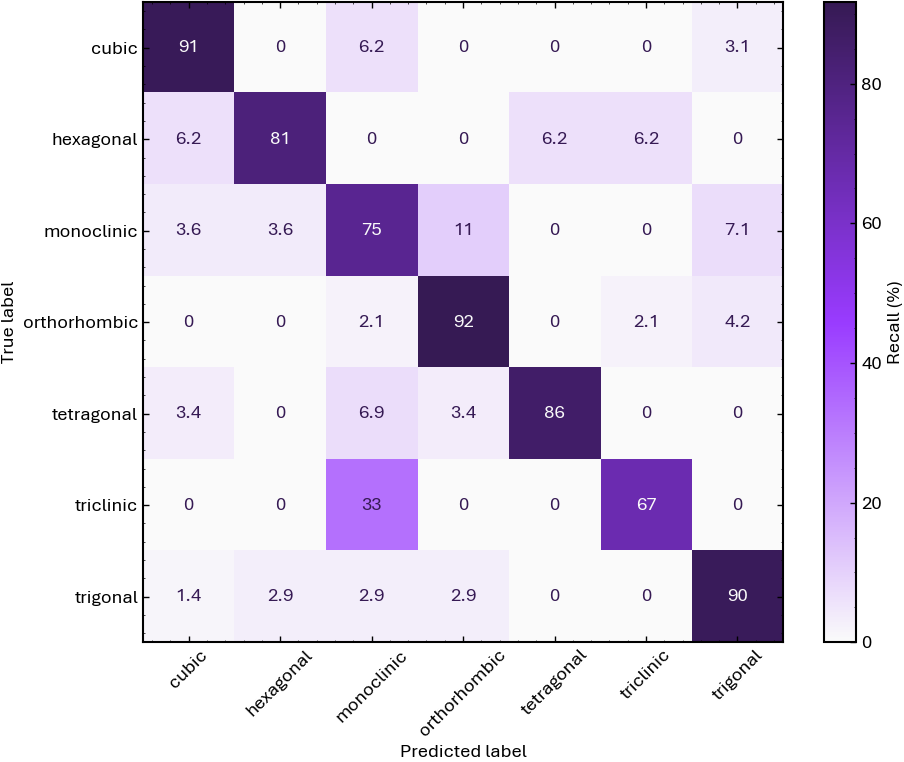

In [16]:
import matplotlib.colors
# Get predictions from your best model (etc)
etc_model = classic_models['etc']

# Retrain on train+val
etc_model.fit(X_train_final, y_train_final)
y_pred = etc_model.predict(X_test)

# Get class labels from your label mapping
class_labels = [label_mapping[i] for i in sorted(label_mapping.keys())]

custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fafafa", "#993bff", "#361a54"])

# Normalised version (shows % of each true class correctly predicted)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
cm_percent = (cm_norm * 100).round(1)  # convert to percentages rounded to 1dp

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_labels)
disp.plot(ax=ax, cmap=custom_cmap, colorbar=True, xticks_rotation=45)
disp.im_.colorbar.set_label('Recall (%)')
    
plt.tight_layout()
# plt.savefig('confusion_matrix_etc_normalised.png', dpi=300, bbox_inches='tight')
plt.show()